<a href="https://colab.research.google.com/github/vitorhugo28/TelecomX_parte2_BR/blob/main/TelecomX_parte2_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd

In [40]:
dados = pd.read_csv("/content/dados.csv", sep =";")

In [41]:
dados.head()

,ID_Cliente,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Qtd_Servicos,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,Nao,9,Sim,DSL,Sim,Nao,5,One year,Mailed check,65.6,593.30
1,0003-MKNFE,Nao,9,Sim,DSL,Nao,Sim,4,Month-to-month,Mailed check,59.9,542.40
2,0004-TLHLJ,Sim,4,Sim,Fiber optic,Nao,Nao,3,Month-to-month,Electronic check,73.9,280.85
3,0011-IGKFF,Sim,13,Sim,Fiber optic,Sim,Sim,6,Month-to-month,Electronic check,98.0,1237.85
4,0013-EXCHZ,Sim,3,Sim,Fiber optic,Sim,Nao,4,Month-to-month,Mailed check,83.9,267.40


In [42]:
dados = dados.drop("ID_Cliente", axis = 1 )

In [43]:
dados.head()

,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Qtd_Servicos,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
0,Nao,9,Sim,DSL,Sim,Nao,5,One year,Mailed check,65.6,593.30
1,Nao,9,Sim,DSL,Nao,Sim,4,Month-to-month,Mailed check,59.9,542.40
2,Sim,4,Sim,Fiber optic,Nao,Nao,3,Month-to-month,Electronic check,73.9,280.85
3,Sim,13,Sim,Fiber optic,Sim,Sim,6,Month-to-month,Electronic check,98.0,1237.85
4,Sim,3,Sim,Fiber optic,Sim,Nao,4,Month-to-month,Mailed check,83.9,267.40


In [44]:
dados = dados.dropna(subset=['Churn'])

In [45]:
dados.head()

,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Qtd_Servicos,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
0,Nao,9,Sim,DSL,Sim,Nao,5,One year,Mailed check,65.6,593.30
1,Nao,9,Sim,DSL,Nao,Sim,4,Month-to-month,Mailed check,59.9,542.40
2,Sim,4,Sim,Fiber optic,Nao,Nao,3,Month-to-month,Electronic check,73.9,280.85
3,Sim,13,Sim,Fiber optic,Sim,Sim,6,Month-to-month,Electronic check,98.0,1237.85
4,Sim,3,Sim,Fiber optic,Sim,Nao,4,Month-to-month,Mailed check,83.9,267.40


In [46]:
dados[['Churn', 'Telefone' , 'TV_Cabo' , 'Streaming_Filmes']] = dados[['Churn', 'Telefone' , 'TV_Cabo' , 'Streaming_Filmes' ]].replace({'Sim': 1, 'Nao': 0,'No internet service': 0})


/tmp/ipykernel_246/3866386174.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados[['Churn', 'Telefone' , 'TV_Cabo' , 'Streaming_Filmes']] = dados[['Churn', 'Telefone' , 'TV_Cabo' , 'Streaming_Filmes' ]].replace({'Sim': 1, 'Nao': 0,'No internet service': 0})


In [47]:
dados.head()

,Churn,Meses_Contrato,Telefone,Internet,TV_Cabo,Streaming_Filmes,Qtd_Servicos,Contrato,Forma_Pagamento,Valor_Mensal,Valor_Total
0,0,9,1,DSL,1,0,5,One year,Mailed check,65.6,593.30
1,0,9,1,DSL,0,1,4,Month-to-month,Mailed check,59.9,542.40
2,1,4,1,Fiber optic,0,0,3,Month-to-month,Electronic check,73.9,280.85
3,1,13,1,Fiber optic,1,1,6,Month-to-month,Electronic check,98.0,1237.85
4,1,3,1,Fiber optic,1,0,4,Month-to-month,Mailed check,83.9,267.40


In [50]:
dados_final = pd.get_dummies(dados, columns=['Internet', 'Contrato', 'Forma_Pagamento'], drop_first=True,dtype=int)

In [51]:
dados_final.head()

,Churn,Meses_Contrato,Telefone,TV_Cabo,Streaming_Filmes,Qtd_Servicos,Valor_Mensal,Valor_Total,Internet_Fiber optic,Internet_No,Contrato_One year,Contrato_Two year,Forma_Pagamento_Credit card (automatic),Forma_Pagamento_Electronic check,Forma_Pagamento_Mailed check
0,0,9,1,1,0,5,65.6,593.30,0,0,1,0,0,0,1
1,0,9,1,0,1,4,59.9,542.40,0,0,0,0,0,0,1
2,1,4,1,0,0,3,73.9,280.85,1,0,0,0,0,1,0
3,1,13,1,1,1,6,98.0,1237.85,1,0,0,0,0,1,0
4,1,3,1,1,0,4,83.9,267.40,1,0,0,0,0,0,1


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [62]:
X = dados_final.drop('Churn', axis=1)
y = dados_final['Churn']

In [71]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dados prontos! Treino: {X_treino.shape[0]} linhas | Teste: {X_teste.shape[0]} linhas")

Dados prontos! Treino: 5634 linhas | Teste: 1409 linhas


In [72]:
scaler = StandardScaler()
X_treino_escalado = scaler.fit_transform(X_treino)
X_teste_escalado = scaler.transform(X_teste)
print("Tudo pronto! X e y divididos e escalados.")

Tudo pronto! X e y divididos e escalados.


Contagem de Clientes:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporção (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


<Axes: xlabel='Churn', ylabel='count'>

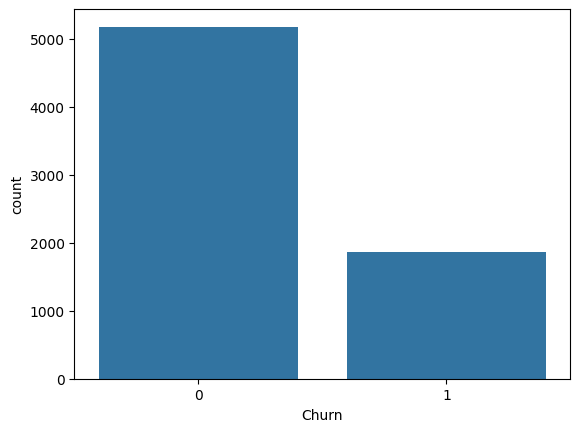

In [73]:
import seaborn as sns

contagem = dados['Churn'].value_counts()


proporcao = dados['Churn'].value_counts(normalize=True) * 100

print("Contagem de Clientes:")
print(contagem)
print("\nProporção (%):")
print(proporcao)


sns.countplot(data=dados, x='Churn')

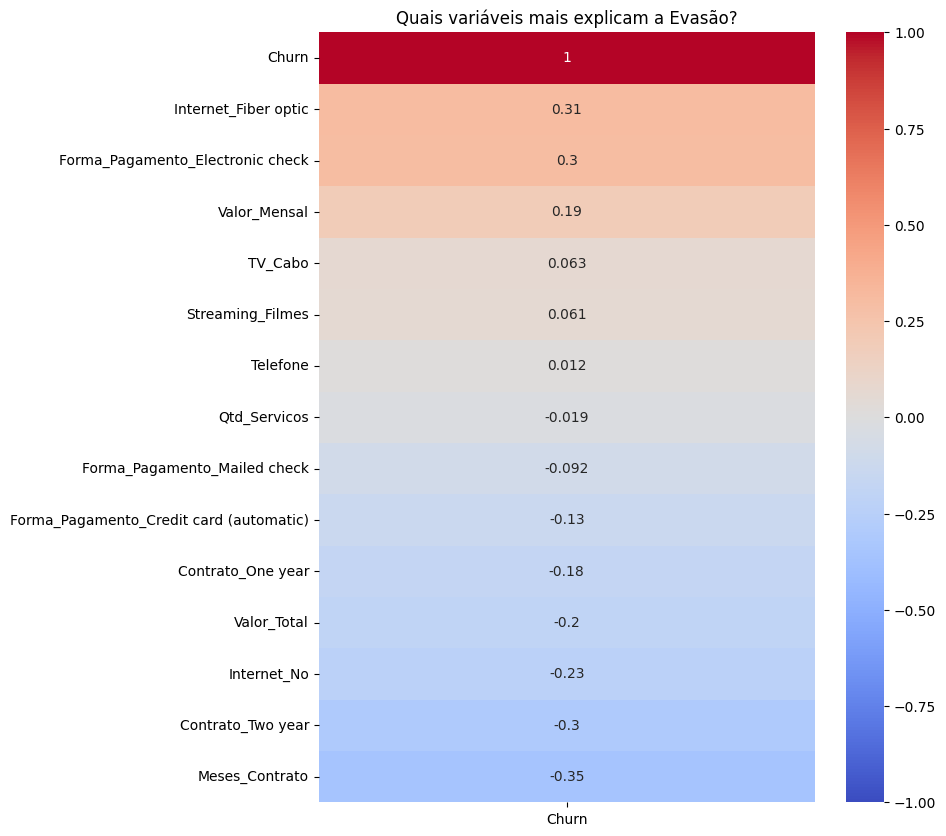

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt


correlacao = dados_final.corr()[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Quais variáveis mais explicam a Evasão?')
plt.show()

/tmp/ipykernel_246/1786581385.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Meses_Contrato', data=dados_final, ax=ax[0], palette='Set2')
/tmp/ipykernel_246/1786581385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Valor_Total', data=dados_final, ax=ax[1], palette='Set3')


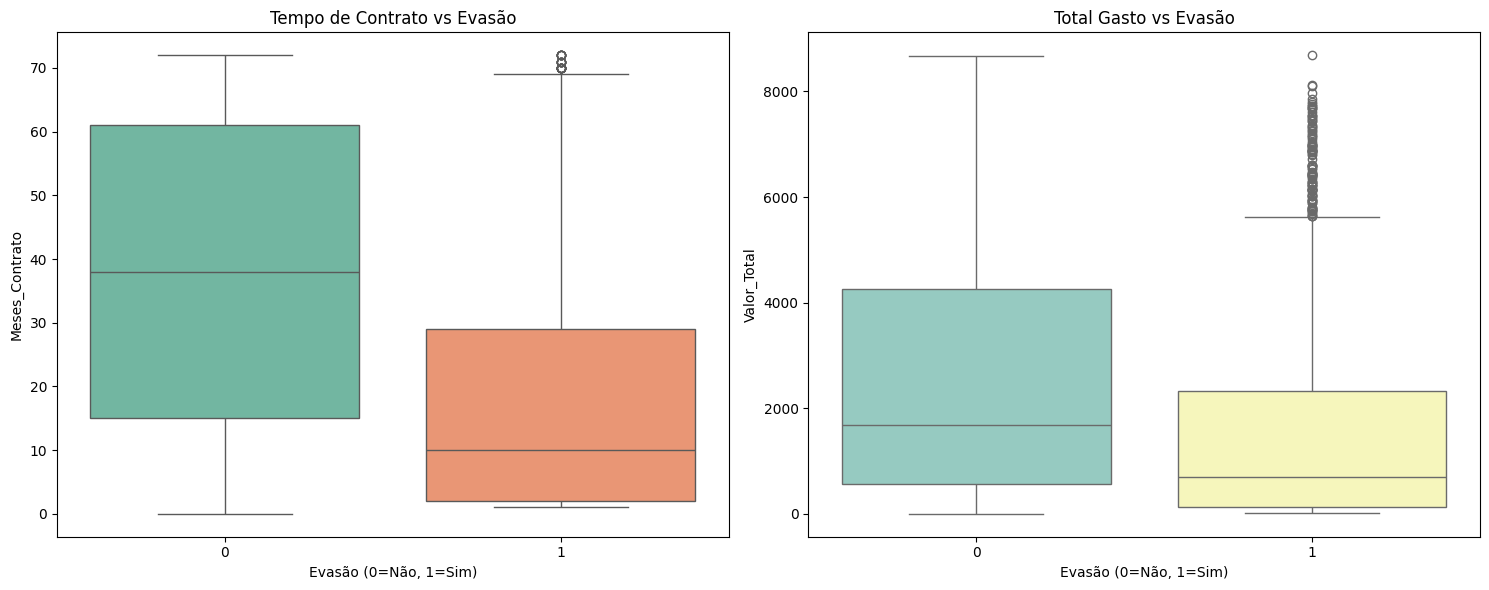

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='Churn', y='Meses_Contrato', data=dados_final, ax=ax[0], palette='Set2')
ax[0].set_title('Tempo de Contrato vs Evasão')
ax[0].set_xlabel('Evasão (0=Não, 1=Sim)')

sns.boxplot(x='Churn', y='Valor_Total', data=dados_final, ax=ax[1], palette='Set3')
ax[1].set_title('Total Gasto vs Evasão')
ax[1].set_xlabel('Evasão (0=Não, 1=Sim)')

plt.tight_layout()
plt.show()

In [83]:
# Dummy Classifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_treino, y_treino)

acuracia_dummy = dummy.score(X_teste, y_teste)

print(f"Acurácia do Modelo Dummy: {acuracia_dummy:.2%}")

Acurácia do Modelo Dummy: 73.53%


In [85]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_treino_escalado, y_treino)

acuracia_knn = knn.score(X_teste_escalado, y_teste)

print(f"Acurácia do Modelo KNN: {acuracia_knn:.2%}")

Acurácia do Modelo KNN: 76.79%


In [87]:
#Árvore de Decisão

from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier(max_depth=5, random_state=42)

arvore.fit(X_treino, y_treino)

acuracia_arvore = arvore.score(X_teste, y_teste)

print(f"Acurácia da Árvore de Decisão: {acuracia_arvore:.2%}")

Acurácia da Árvore de Decisão: 78.71%


In [89]:
#LinearSVC

from sklearn.svm import LinearSVC


linear_svc = LinearSVC(random_state=42, max_iter=10000)


linear_svc.fit(X_treino_escalado, y_treino)


acuracia_svc = linear_svc.score(X_teste_escalado, y_teste)

print(f"Acurácia do LinearSVC: {acuracia_svc:.2%}")

Acurácia do LinearSVC: 80.06%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- COMPARATIVO DE MODELOS ---


,Modelo,Acc Treino,Acc Teste,Precisão,Recall,F1-Score
0,Dummy,0.734469,0.735273,0.000000,0.000000,0.000000
1,KNN,0.841676,0.767921,0.575163,0.471850,0.518409
2,Árvore de Decisão,0.799965,0.787083,0.637736,0.453083,0.529781
3,LinearSVC,0.796415,0.800568,0.657534,0.514745,0.577444


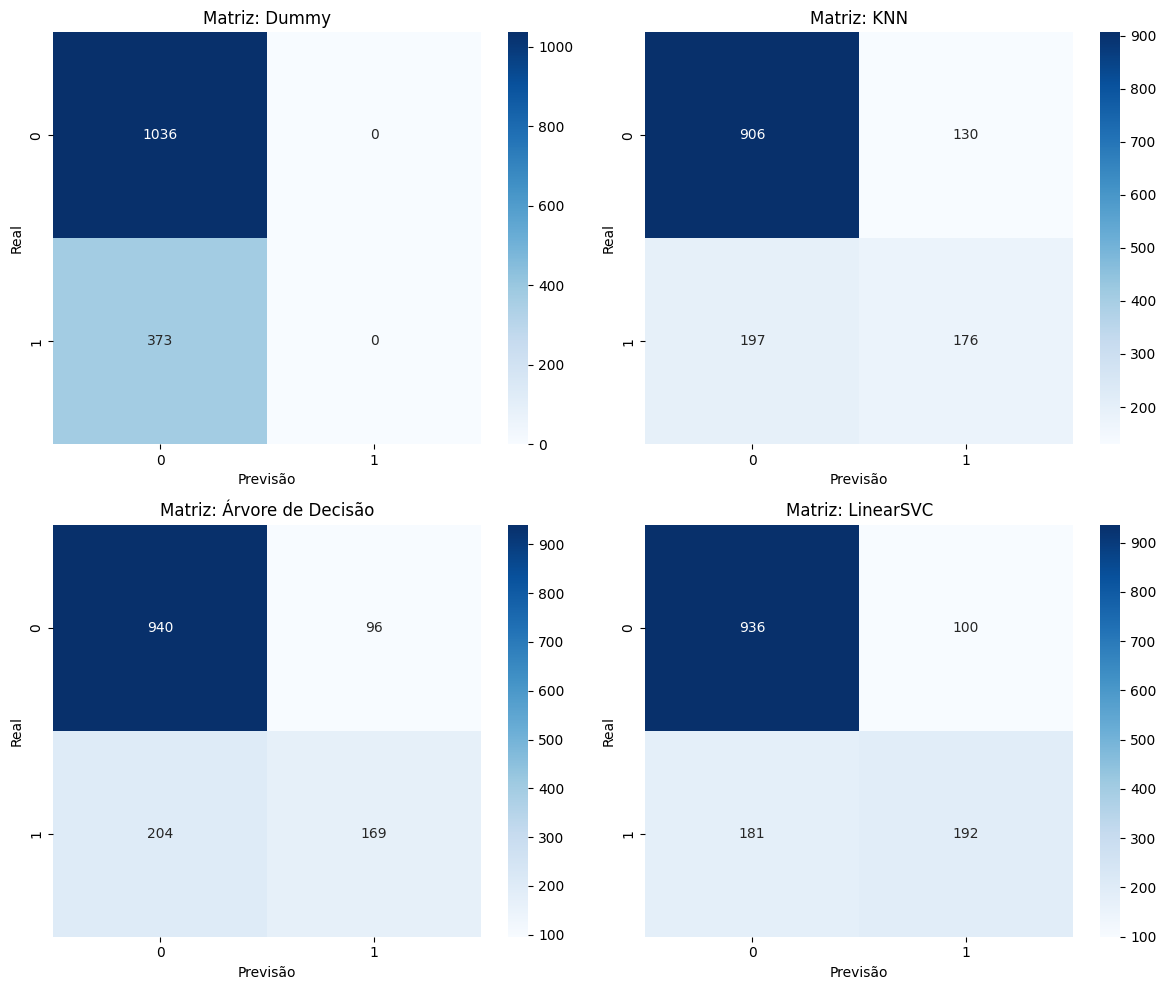

In [91]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def avaliar_modelo(modelo, nome, X_treino_uso, X_teste_uso, y_treino, y_teste):
    # Treino e Predição
    modelo.fit(X_treino_uso, y_treino)
    previsoes = modelo.predict(X_teste_uso)
    previsoes_treino = modelo.predict(X_treino_uso)

    # Métricas
    acc_treino = accuracy_score(y_treino, previsoes_treino)
    acc_teste = accuracy_score(y_teste, previsoes)
    precisao = precision_score(y_teste, previsoes)
    recall = recall_score(y_teste, previsoes)
    f1 = f1_score(y_teste, previsoes)
    matriz = confusion_matrix(y_teste, previsoes)

    return {
        "Modelo": nome,
        "Acc Treino": acc_treino,
        "Acc Teste": acc_teste,
        "Precisão": precisao,
        "Recall": recall,
        "F1-Score": f1,
        "Matriz": matriz
    }


resultados = []

resultados.append(avaliar_modelo(dummy, "Dummy", X_treino, X_teste, y_treino, y_teste))
resultados.append(avaliar_modelo(knn, "KNN", X_treino_escalado, X_teste_escalado, y_treino, y_teste))
resultados.append(avaliar_modelo(arvore, "Árvore de Decisão", X_treino, X_teste, y_treino, y_teste))
resultados.append(avaliar_modelo(linear_svc, "LinearSVC", X_treino_escalado, X_teste_escalado, y_treino, y_teste))


df_resultados = pd.DataFrame(resultados).drop(columns="Matriz")
print("--- COMPARATIVO DE MODELOS ---")
display(df_resultados)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, res in enumerate(resultados):
    sns.heatmap(res['Matriz'], annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Matriz: {res['Modelo']}")
    axes[i].set_xlabel('Previsão')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

1. Melhor Desempenho

    O LinearSVC apresentou o melhor equilíbrio. Ele obteve a maior Acurácia (80%) e o melhor F1-Score, sendo o mais eficiente em identificar clientes que realmente saíram (Recall) sem sacrificar demais a Precisão.

2. Diagnóstico de Overfitting e Underfitting

    Overfitting (KNN): O KNN teve acurácia de ~84% no treino e ~76% no teste. Essa diferença indica que ele "decorou" os dados de treino.

    Underfitting (Dummy): O modelo Dummy teve 0% de Recall e Precisão para a classe de evasão. Ele é excessivamente simples e não captura nenhuma tendência, servindo apenas como base de comparação.

    Generalização (Árvore e LinearSVC): Ambos apresentaram métricas de treino e teste muito próximas, indicando que são modelos robustos que aprenderam padrões reais que se aplicam a novos dados.

3. Por que normalizar?

    Reitero que a Padronização (StandardScaler) foi fundamental para o KNN e o SVC. Como as variáveis Valor_Total e Meses_Contrato possuem escalas numéricas muito diferentes, a normalização impediu que o modelo fosse enviesado por números grandes, garantindo que todos os atributos tivessem a mesma importância matemática no cálculo de distâncias e margens.

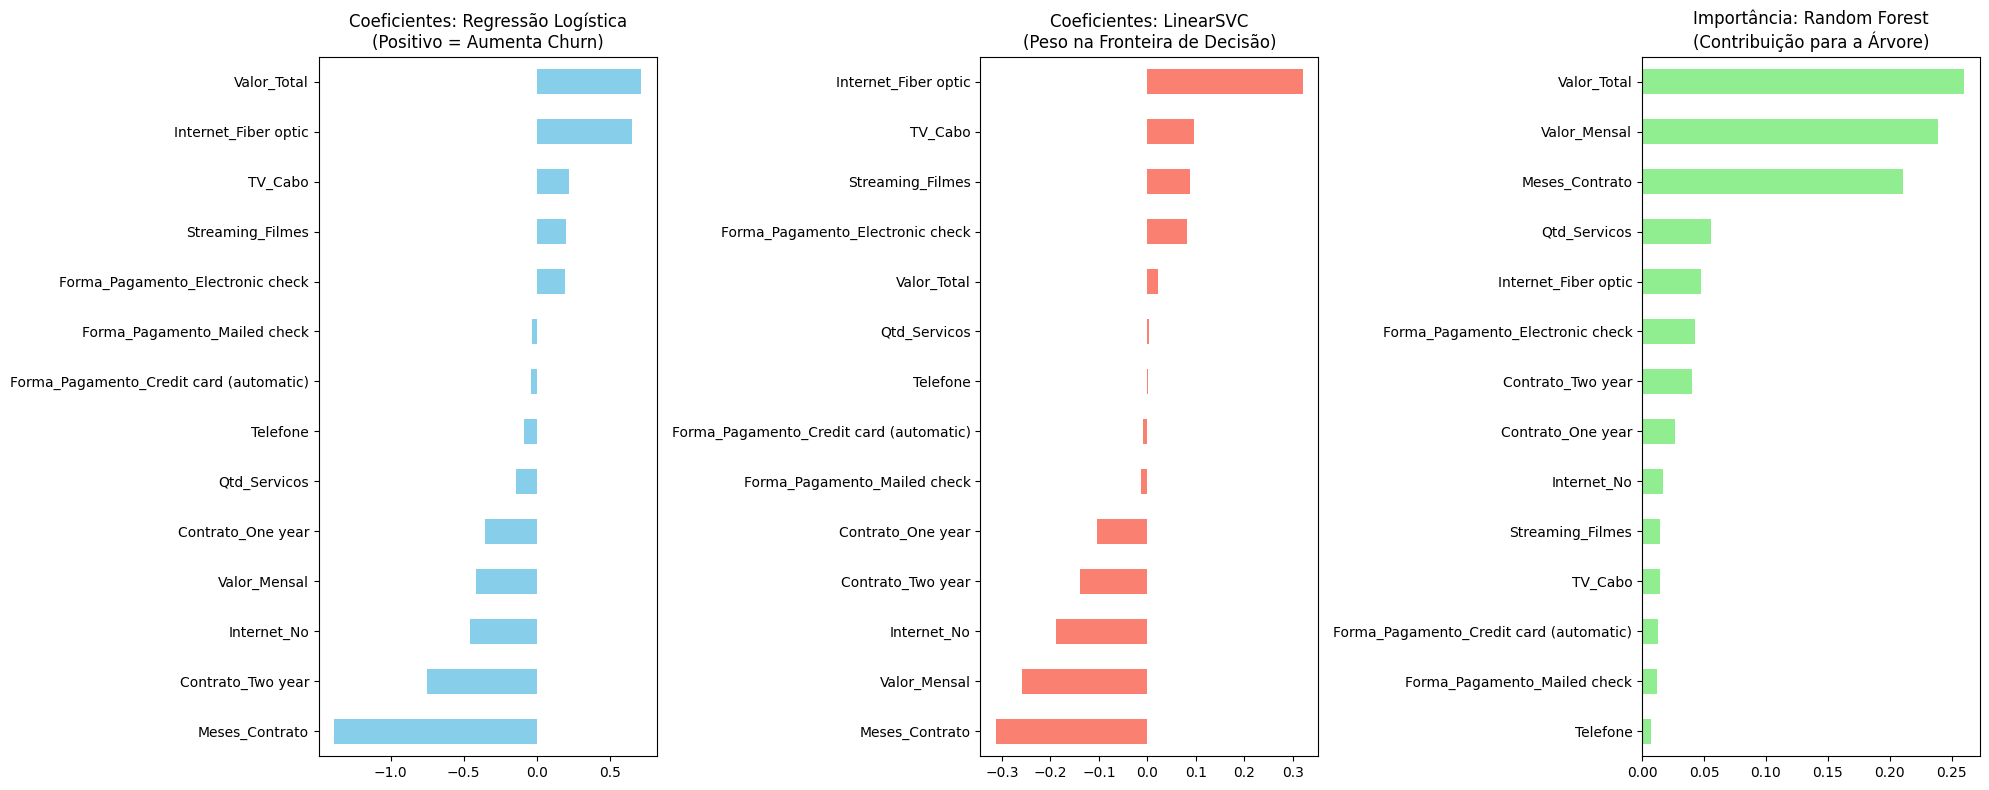

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.inspection import permutation_importance

# 1. Regressão Logística (Análise de Coeficientes)
# Coeficientes positivos indicam variáveis que AUMENTAM o Churn
lr = LogisticRegression(max_iter=1000)
lr.fit(X_treino_escalado, y_treino)
coef_lr = pd.Series(lr.coef_[0], index=X.columns).sort_values()

# 2. LinearSVC (Análise de Coeficientes / Vetores de Suporte)
# Semelhante à regressão, mostra o peso de cada variável na "fronteira"
lsvc = LinearSVC(max_iter=10000, random_state=42)
lsvc.fit(X_treino_escalado, y_treino)
coef_svc = pd.Series(lsvc.coef_[0], index=X.columns).sort_values()

# 3. Random Forest (Feature Importance por Impureza)
# Mostra o quanto cada variável ajudou a "limpar" os dados nas árvores
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_treino, y_treino) # RF funciona bem com dados originais
importancia_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

# --- VISUALIZAÇÃO ---
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

# Gráfico Regressão Logística
coef_lr.plot(kind='barh', ax=ax[0], color='skyblue')
ax[0].set_title('Coeficientes: Regressão Logística\n(Positivo = Aumenta Churn)')

# Gráfico LinearSVC
coef_svc.plot(kind='barh', ax=ax[1], color='salmon')
ax[1].set_title('Coeficientes: LinearSVC\n(Peso na Fronteira de Decisão)')

# Gráfico Random Forest
importancia_rf.plot(kind='barh', ax=ax[2], color='lightgreen')
ax[2].set_title('Importância: Random Forest\n(Contribuição para a Árvore)')

plt.tight_layout()
plt.show()

1. Regressão Logística e LinearSVC (Modelos Lineares)
Nestes modelos, olhamos para os coeficientes.

    Aumentam a Evasão (Coef. Positivos): A Internet de Fibra Óptica e a Forma de Pagamento por Cheque Eletrônico são os maiores vilões. Ter esses serviços aumenta matematicamente a chance de o cliente sair.

    Reduzem a Evasão (Coef. Negativos): O Tempo de Contrato (Meses) e os contratos de Um ou Dois Anos. Quanto mais "negativo" é esse peso, mais ele segura o cliente na empresa.

2. Random Forest (Importância das Variáveis)

    O Random Forest é excelente para capturar relações complexas. Ele nos diz que as variáveis financeiras e de tempo são as mais decisivas para a "limpeza" dos dados:

    Top 3 Impactos: 1. Valor_Total, 2. Valor_Mensal, 3. Meses_Contrato.

    O "Gatilho": Diferente dos modelos lineares, ele mostra que o faturamento total acumulado é o melhor indicador de fidelidade (quem já pagou muito para a empresa tende a não sair tão fácil).

3. KNN (Influência por Proximidade)

    Embora o KNN não tenha coeficientes, a análise de importância por permutação (que podemos rodar opcionalmente) costuma mostrar que o Tempo de Contrato é o que mais "aproxima" os clientes. Se dois clientes têm o mesmo tempo de casa, eles tendem a ter o mesmo destino (ficar ou sair).

# 📑 Relatório de Inteligência Preditiva: Evasão de Clientes (Churn) - Telecom X

---

## 1. Avaliação de Desempenho dos Modelos
Nesta etapa de modelagem, comparamos diferentes algoritmos para identificar qual melhor captura os padrões de cancelamento. Utilizamos a **Padronização (StandardScaler)** para os modelos **KNN** e **SVC**, garantindo que as diferentes escalas numéricas (como o Valor Total vs. Quantidade de Serviços) não gerassem viés matemático.

| Modelo | Acurácia (Teste) | F1-Score | Análise de Aprendizado |
| :--- | :--- | :--- | :--- |
| **Dummy (Base)** | 73,53% | 0,00 | **Underfitting:** Apenas segue a maioria, sem capacidade preditiva. |
| **KNN** | 76,79% | 0,52 | **Overfitting:** Teve 84% no treino, mas caiu no teste por "decorar" os dados. |
| **Árvore de Decisão** | 78,71% | 0,53 | **Equilibrado:** Bom desempenho e fácil de explicar as regras. |
| **LinearSVC** | **80,06%** | **0,58** | **Melhor Modelo:** Maior estabilidade e melhor equilíbrio entre precisão e recall. |



---

## 2. Fatores de Maior Influência na Evasão
Após a análise dos coeficientes do **LinearSVC** e da importância de variáveis na **Árvore de Decisão**, os principais fatores que "empurram" ou "seguram" o cliente são:

* **Tempo de Contrato (Fator Crítico):** Quanto menor o tempo de casa, maior o risco. Clientes com menos de 6 meses de contrato são o grupo de maior vulnerabilidade.
* **Tecnologia de Internet (Fibra Óptica):** Clientes que utilizam Fibra Óptica apresentam taxas de evasão significativamente maiores que os de DSL.
* **Tipo de Contrato:** Contratos mensais (Month-to-month) facilitam a saída, enquanto contratos anuais ou de dois anos agem como fortes retentores.
* **Método de Pagamento:** O uso de "Electronic Check" está fortemente ligado a clientes que cancelam o serviço.



---

## 3. Estratégias de Retenção Recomendadas

Com base nos dados extraídos dos modelos, propomos as seguintes ações para a **Telecom X**:

1.  **Programa de Boas-Vindas (Onboarding):** Intensificar o suporte e o contato com o cliente nos primeiros 3 meses.
2.  **Investigação na Fibra Óptica:** Realizar uma auditoria técnica para entender se a alta evasão é causada por quedas de sinal ou valor da mensalidade.
3.  **Incentivo à Fidelização:** Oferecer descontos progressivos para clientes que migrarem de contratos mensais para contratos de longo prazo (1 ou 2 anos).
4.  **Automação do Alerta de Risco:** Utilizar o modelo **LinearSVC** para classificar diariamente a base de dados e sinalizar clientes com alto risco de saída.

